In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
df = pd.read_csv("Titanic_train.csv")

In [3]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
df.shape

(891, 16)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PassengerId    891 non-null    int64  
 1   Survived       891 non-null    int64  
 2   Pclass         891 non-null    int64  
 3   Name           891 non-null    object 
 4   Sex            891 non-null    object 
 5   Age            891 non-null    float64
 6   SibSp          891 non-null    int64  
 7   Parch          891 non-null    int64  
 8   Ticket         891 non-null    object 
 9   Fare           891 non-null    float64
 10  Cabin          204 non-null    object 
 11  Embarked       891 non-null    object 
 12  Title          891 non-null    object 
 13  Members        891 non-null    int64  
 14  IsAlone        891 non-null    int64  
 15  FarePerPerson  891 non-null    float64
dtypes: float64(3), int64(7), object(6)
memory usage: 111.5+ KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Members,IsAlone,FarePerPerson
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.066409,0.523008,0.381594,32.204208,0.904602,0.602694,19.916375
std,257.353842,0.486592,0.836071,13.244532,1.102743,0.806057,49.693429,1.613459,0.489615,35.841257
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400,0.000000,0.000000,7.250000
50%,446.000000,0.000000,3.000000,26.000000,0.000000,0.000000,14.454200,0.000000,1.000000,8.300000
75%,668.500000,1.000000,3.000000,37.000000,1.000000,0.000000,31.000000,1.000000,1.000000,23.666667
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,10.000000,1.000000,512.329200


# Dataset Preprocessing 

In [8]:
df.drop( columns = ["PassengerId", "Ticket", "Cabin"], inplace = True)

In [9]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Members,IsAlone,FarePerPerson
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,Mr,1,0,3.62500
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,Mrs,1,0,35.64165
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,Miss,0,1,7.92500
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,Mrs,1,0,26.55000
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,Mr,0,1,8.05000


In [10]:
df["Members"] = df["SibSp"] + df["Parch"]

In [11]:
#df.drop( columns = ["SibSp", "Parch"], inplace = True)

In [12]:
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Members,IsAlone,FarePerPerson
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,Mr,1,0,3.62500
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,Mrs,1,0,35.64165
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,Miss,0,1,7.92500
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,Mrs,1,0,26.55000
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,Mr,0,1,8.05000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,13.0000,S,Other,0,1,13.00000
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,30.0000,S,Miss,0,1,30.00000
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,24.0,1,2,23.4500,S,Miss,3,0,5.86250
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,30.0000,C,Mr,0,1,30.00000


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Survived       891 non-null    int64  
 1   Pclass         891 non-null    int64  
 2   Name           891 non-null    object 
 3   Sex            891 non-null    object 
 4   Age            891 non-null    float64
 5   SibSp          891 non-null    int64  
 6   Parch          891 non-null    int64  
 7   Fare           891 non-null    float64
 8   Embarked       891 non-null    object 
 9   Title          891 non-null    object 
 10  Members        891 non-null    int64  
 11  IsAlone        891 non-null    int64  
 12  FarePerPerson  891 non-null    float64
dtypes: float64(3), int64(6), object(4)
memory usage: 90.6+ KB


In [14]:
df["Sex"] = df["Sex"].astype("category")
df["Embarked"] = df["Embarked"].astype("category")

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Survived       891 non-null    int64   
 1   Pclass         891 non-null    int64   
 2   Name           891 non-null    object  
 3   Sex            891 non-null    category
 4   Age            891 non-null    float64 
 5   SibSp          891 non-null    int64   
 6   Parch          891 non-null    int64   
 7   Fare           891 non-null    float64 
 8   Embarked       891 non-null    category
 9   Title          891 non-null    object  
 10  Members        891 non-null    int64   
 11  IsAlone        891 non-null    int64   
 12  FarePerPerson  891 non-null    float64 
dtypes: category(2), float64(3), int64(6), object(2)
memory usage: 78.7+ KB


In [16]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare,Members,IsAlone,FarePerPerson
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.066409,0.523008,0.381594,32.204208,0.904602,0.602694,19.916375
std,0.486592,0.836071,13.244532,1.102743,0.806057,49.693429,1.613459,0.489615,35.841257
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400,0.000000,0.000000,7.250000
50%,0.000000,3.000000,26.000000,0.000000,0.000000,14.454200,0.000000,1.000000,8.300000
75%,1.000000,3.000000,37.000000,1.000000,0.000000,31.000000,1.000000,1.000000,23.666667
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,10.000000,1.000000,512.329200


## Univariate Analysis

Text(0.5, 1.0, 'Fare KDE plot')

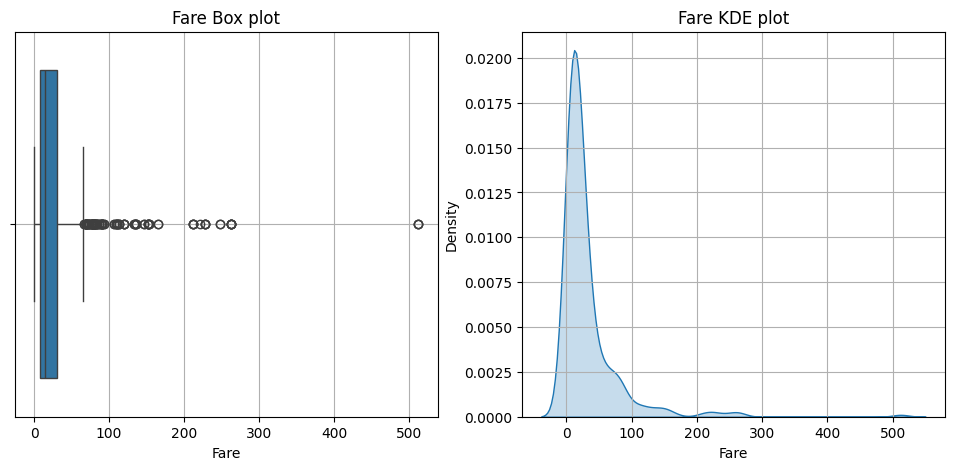

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 5))

sns.boxplot(x = "Fare", data = df, ax = ax1)
ax1.grid(True)
ax1.set_title("Fare Box plot")


sns.kdeplot(x = "Fare", data = df, ax = ax2, fill = True )
ax2.grid(True)
ax2.set_title("Fare KDE plot")

In [17]:
df["Fare"].skew()

np.float64(4.787316519674893)

In [18]:
df["Fare"].var()

np.float64(2469.436845743116)

In [19]:
df["Fare"].mean()

np.float64(32.204207968574636)

Text(0.5, 1.0, 'Age')

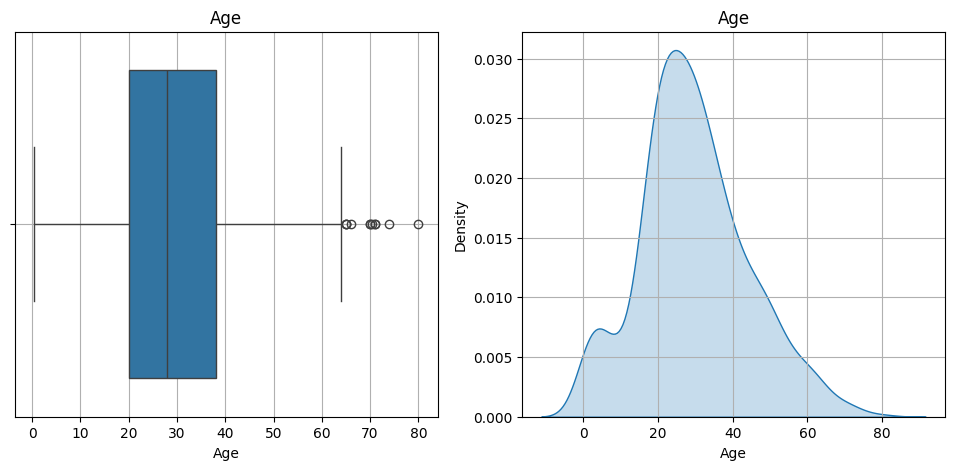

In [20]:
fig, axes = plt.subplots(1,2 , figsize = (12, 5))

sns.boxplot( x = "Age", data = df, ax = axes[0])
axes[0].grid(True)
axes[0].set_title("Age")

sns.kdeplot( x = "Age", data = df, ax = axes[1], fill = True)
axes[1].grid(True)
axes[1].set_title("Age")

In [21]:
df["Age"].skew()

np.float64(0.38910778230082704)

In [22]:
df["Age"].var()

np.float64(211.01912474630802)

In [23]:
df["Age"].mean()

np.float64(29.69911764705882)

<Axes: xlabel='Sex', ylabel='count'>

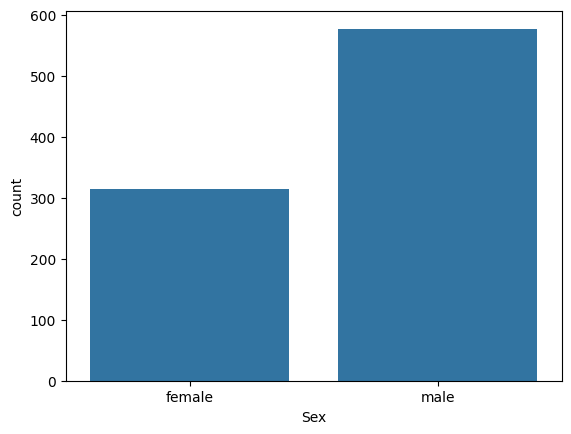

In [24]:
sns.countplot(x= "Sex", data = df)

In [25]:
pd.crosstab(index = df["Embarked"], columns = df["Survived"])

Survived,0,1
Embarked,,
C,75,93
Q,47,30
S,427,217


([<matplotlib.patches.Wedge at 0x216ce654dc0>,
 [Text(-0.7128398816865827, 0.8377704357859967, 'S'),
  Text(0.4614526582133295, -0.9985296411363321, 'C'),
  Text(1.2521691314951144, -0.34938870349622186, 'Q')],
 [Text(-0.3888217536472269, 0.45696569224690725, '72.44%'),
  Text(0.2517014499345433, -0.5446525315289084, '18.90%'),
  Text(0.770565619381609, -0.21500843292075186, '8.66%')])

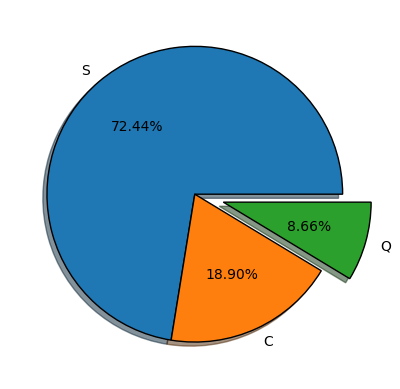

In [26]:
plt.pie(df["Embarked"].value_counts(), labels = ["S","C","Q"], autopct="%1.2f%%", explode = [0,0, 0.2], wedgeprops = {"edgecolor":"black"}, shadow = True)

In [27]:
pd.crosstab(index = df["Pclass"], columns = df["Survived"])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


([<matplotlib.patches.Wedge at 0x216ce06c370>,
 [Text(-0.17571619097547903, 1.085874679799225, '3'),
  Text(-0.5160760536623383, -0.9714244730478574, '1'),
  Text(1.035876847992897, -0.7854674759608451, '2')],
 [Text(-0.09584519507753402, 0.5922952798904862, '55.11%'),
  Text(-0.2814960292703663, -0.5298678943897404, '24.24%'),
  Text(0.6374626756879367, -0.4833646005912892, '20.65%')])

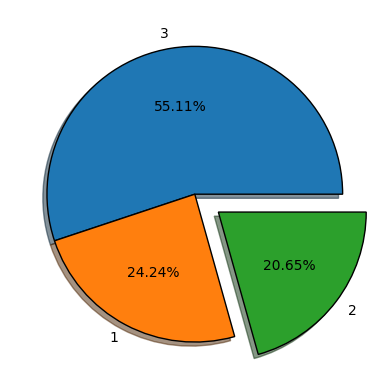

In [28]:
plt.pie(df["Pclass"].value_counts(), labels = [3,1,2], autopct="%1.2f%%", explode = [0,0, 0.2], wedgeprops = {"edgecolor":"black"}, shadow = True)

<Axes: xlabel='Survived', ylabel='count'>

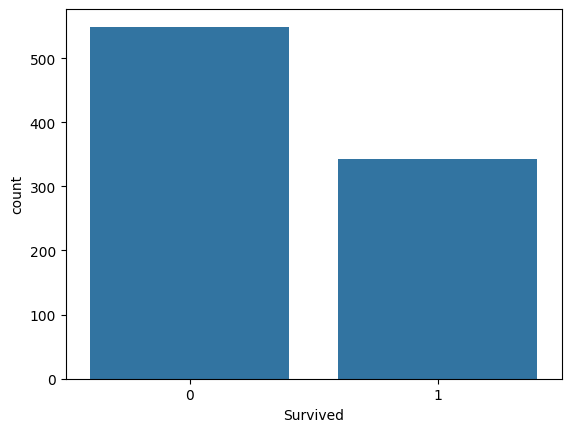

In [29]:
sns.countplot(x = "Survived", data = df)

([<matplotlib.patches.Wedge at 0x216ce0ff970>,
 [Text(-0.39257494735793463, 1.0275626067091557, '0'),
  Text(0.42826354330397, -1.1209774027502646, '1')],
 [Text(-0.21413178946796432, 0.5604886945686304, '61.62%'),
  Text(0.24982040026064914, -0.6539034849376543, '38.38%')])

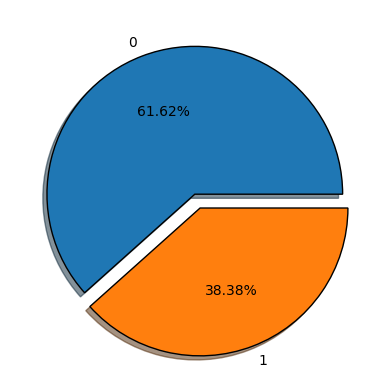

In [30]:
plt.pie(df["Survived"].value_counts(), labels = [0,1], autopct="%1.2f%%", explode = [0,0.1], wedgeprops = {"edgecolor":"black"}, shadow = True)

## Multivariate Analysis

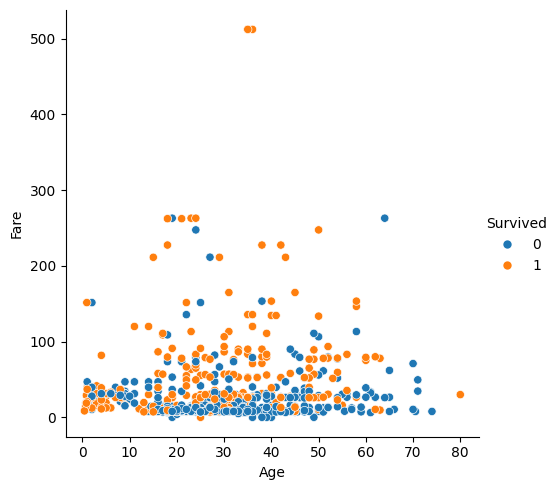

In [31]:
sns.relplot( x = "Age", y = "Fare", data = df, kind = "scatter", hue = "Survived")

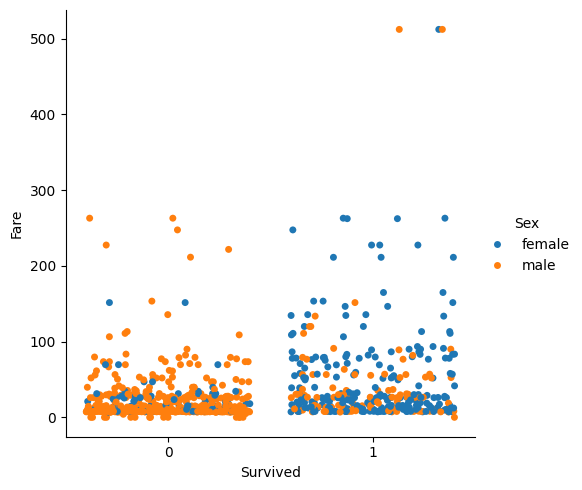

In [32]:
sns.catplot(x = "Survived", y = "Fare", data = df, kind = "strip", jitter = "0.4", hue = "Sex")

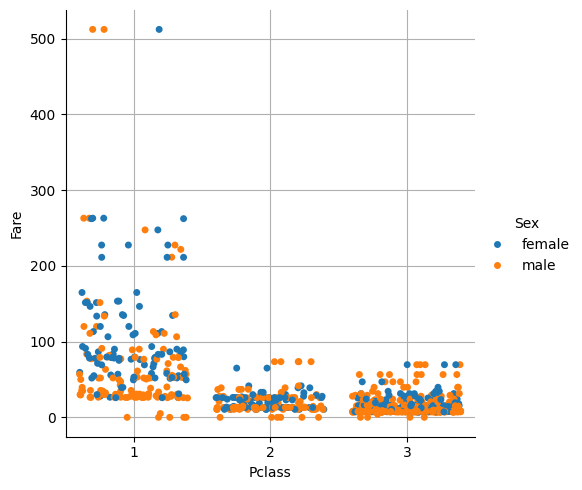

In [33]:
sns.catplot(x = "Pclass", y = "Fare", data = df, kind = "strip", jitter = "0.4", hue ="Sex")
plt.grid(True)

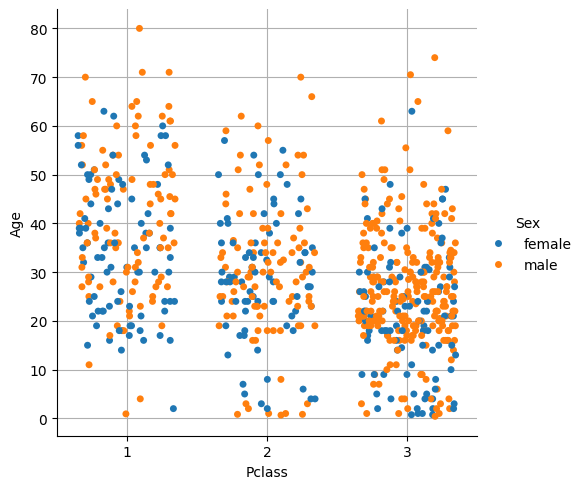

In [34]:
sns.catplot(x = "Pclass", y = "Age", data = df, kind = "strip", jitter = "0.35", hue ="Sex")
plt.grid(True)

In [35]:
x = pd.pivot_table(df, index="Pclass", columns="Survived", values="Fare", aggfunc=sum)

C:\Users\priya\AppData\Local\Temp\ipykernel_33592\3222716614.py:1: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  x = pd.pivot_table(df, index="Pclass", columns="Survived", values="Fare", aggfunc=sum)


In [36]:
x

Survived,0,1
Pclass,,
1,5174.7206,13002.6919
2,1882.9958,1918.8459
3,5085.0035,1629.6916


In [37]:
x = df.drop(columns = ["Name", "Sex", "Embarked"])
xc = x.corr()
xc

,Survived,Pclass,Age,SibSp,Parch,Fare,Members
Survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307,0.016639
Pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500,0.065997
Age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067,-0.301914
SibSp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651,0.890712
Parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225,0.783111
Fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000,0.217138
Members,0.016639,0.065997,-0.301914,0.890712,0.783111,0.217138,1.000000


<Axes: >

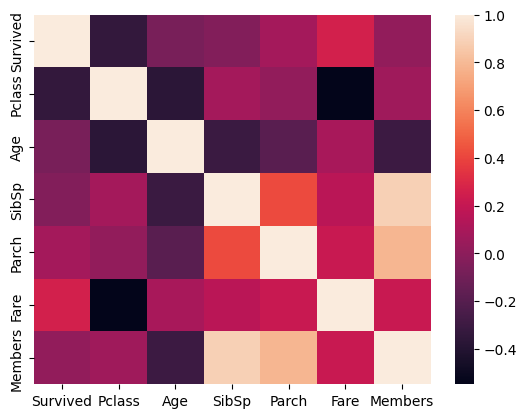

In [38]:
sns.heatmap(xc)

In [39]:
pd.pivot_table( index = "Pclass" , columns = ["Members" , "Survived"] , values = "Fare" , aggfunc = "sum" , data = df)

Members          0                     1                    2              \
Survived          0          1          0          1         0          1   
Pclass                                                                      
1         2106.9998  4833.3042  1562.3125  4867.0502  676.3083  1620.0375   
2          971.1208   491.7542   393.2916   445.9291  437.7542   544.7542   
3         2205.4739   798.6709   499.2586   265.1127  419.4167   350.3623   

Members         3                   4               5                 6   \
Survived         0         1         0       1       0       1         0   
Pclass                                                                     
1         303.1000  631.5500       NaN  524.75  526.00  526.00       NaN   
2          80.8292  394.6584       NaN   23.00     NaN   18.75       NaN   
3          67.4750  113.4582  323.6668     NaN  551.15     NaN  250.3125   

Members                7       10  
Survived         1      0       0  
Pclass                             
1              NaN    NaN     NaN  
2              NaN    NaN     NaN  
3         102.0875  281.4  486.85

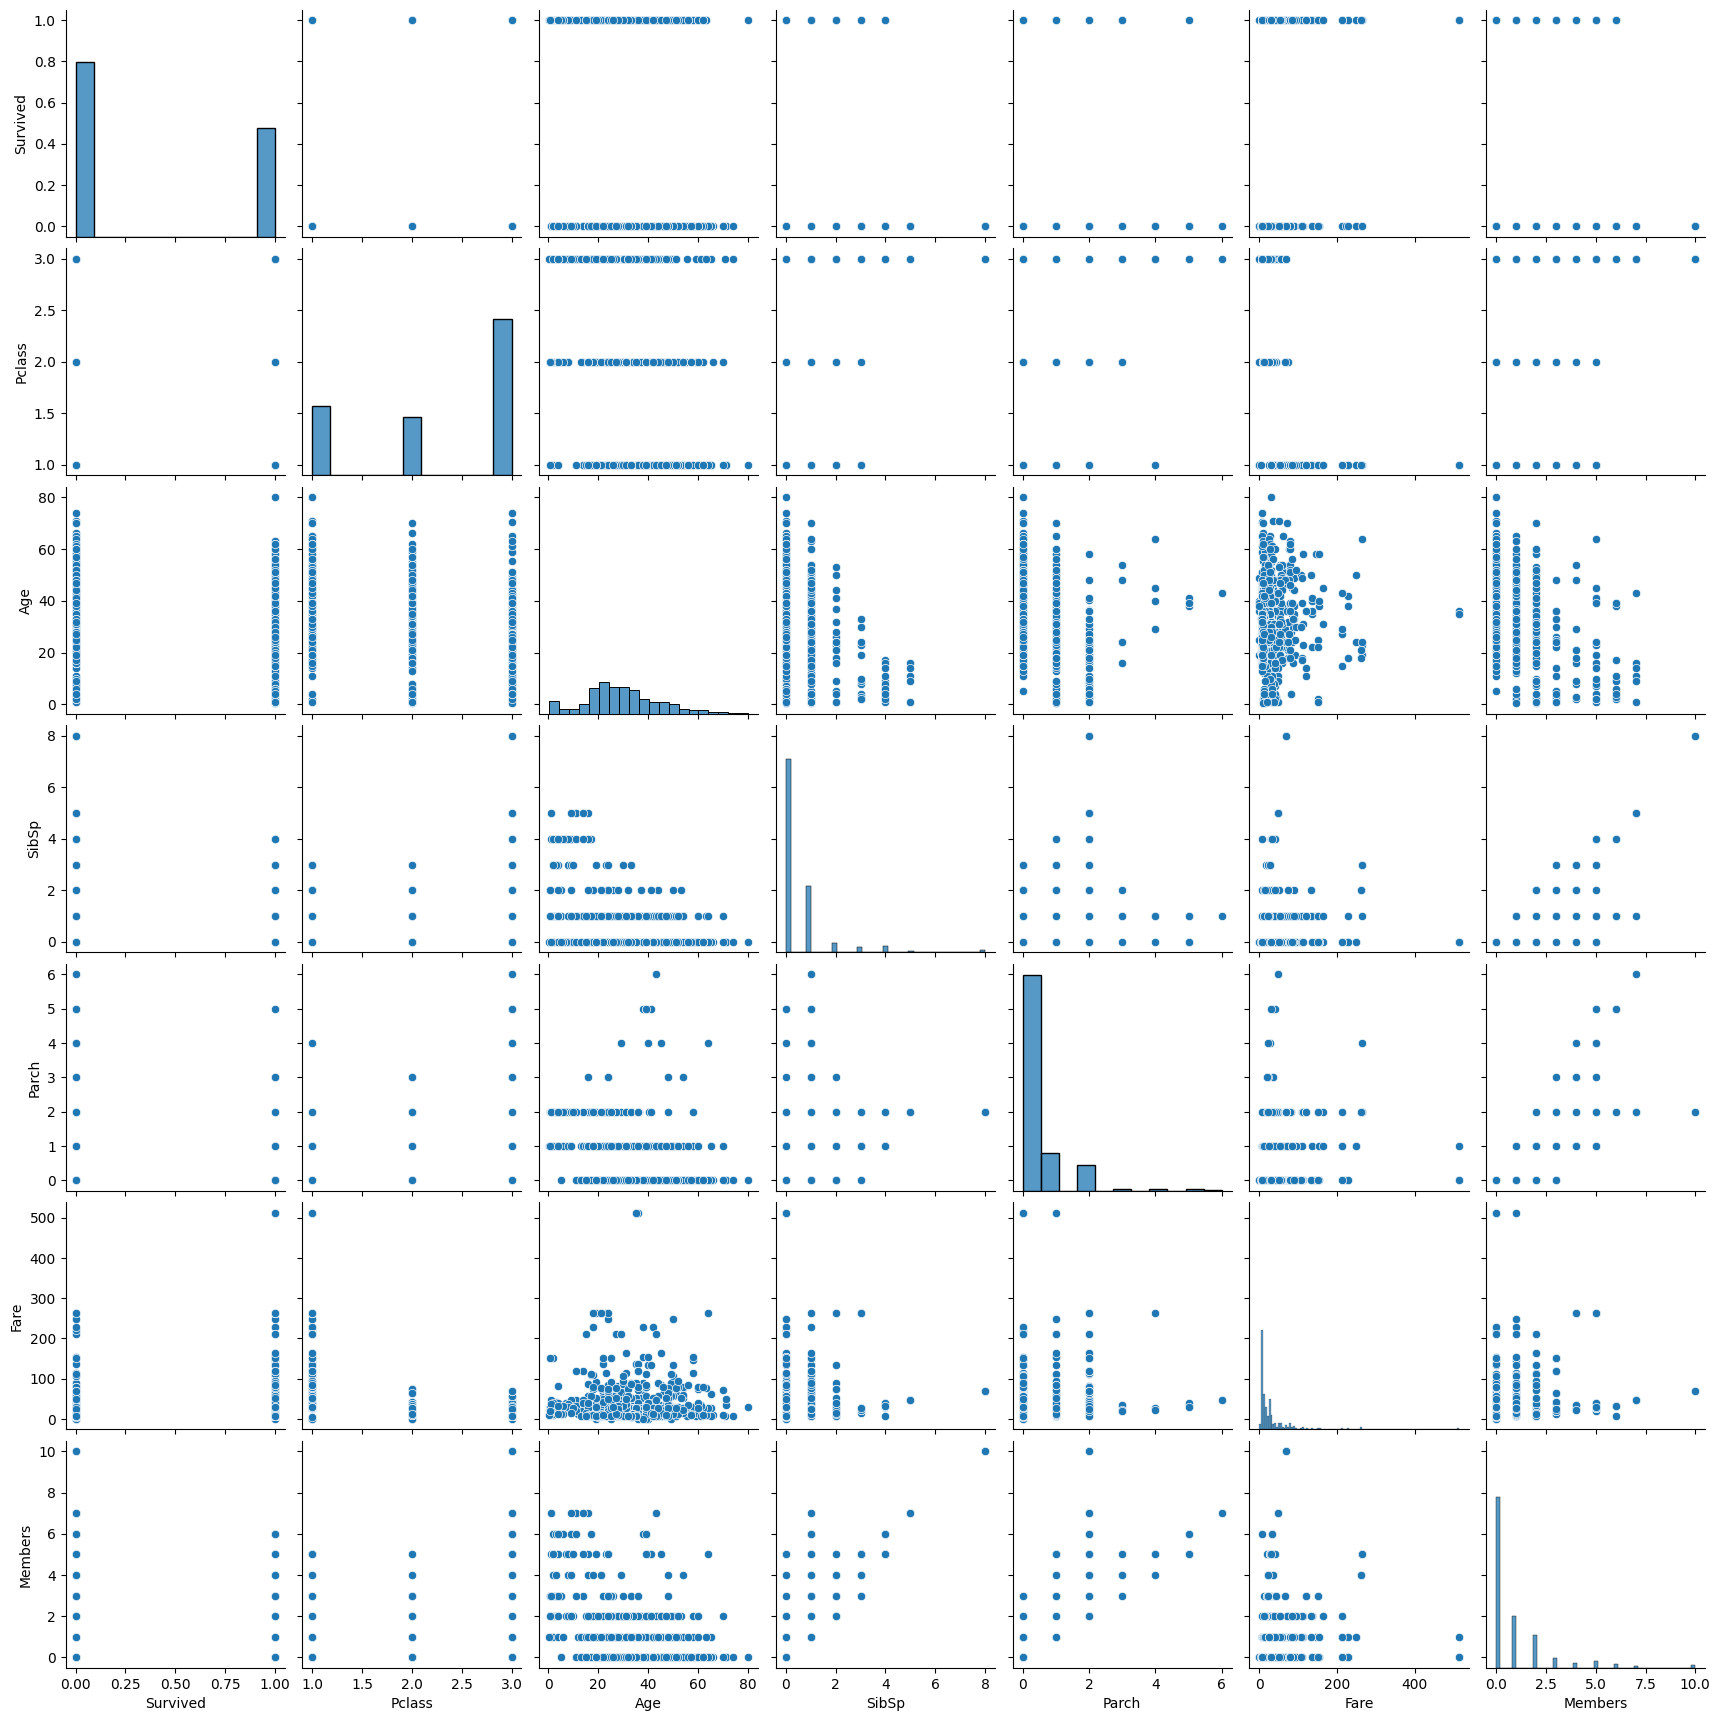

In [40]:
sns.pairplot(df)

## Feature Engineering and Model Training

In [41]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns = "Survived"), 
                                                    df["Survived"], 
                                                    test_size = 0.2, 
                                                    random_state = 42)

In [42]:
X_train = X_train.drop(columns = "Name")
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Members
331,1,male,45.5,0,0,28.5000,S,0
733,2,male,23.0,0,0,13.0000,S,0
382,3,male,32.0,0,0,7.9250,S,0
704,3,male,26.0,1,0,7.8542,S,1
813,3,female,6.0,4,2,31.2750,S,6
...,...,...,...,...,...,...,...,...
106,3,female,21.0,0,0,7.6500,S,0
270,1,male,NaN,0,0,31.0000,S,0
860,3,male,41.0,2,0,14.1083,S,2
435,1,female,14.0,1,2,120.0000,S,3


In [43]:
y_train

331    0
733    0
382    0
704    0
813    0
      ..
106    1
270    0
860    0
435    1
102    0
Name: Survived, Length: 712, dtype: int64

In [44]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

In [45]:
x = list(enumerate(X_train.columns))
x

[(0, 'Pclass'),
 (1, 'Sex'),
 (2, 'Age'),
 (3, 'SibSp'),
 (4, 'Parch'),
 (5, 'Fare'),
 (6, 'Embarked'),
 (7, 'Members')]

In [46]:
X_train.columns

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',
       'Members'],
      dtype='object')

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  891 non-null    int64   
 1   Pclass    891 non-null    int64   
 2   Name      891 non-null    object  
 3   Sex       891 non-null    category
 4   Age       714 non-null    float64 
 5   SibSp     891 non-null    int64   
 6   Parch     891 non-null    int64   
 7   Fare      891 non-null    float64 
 8   Embarked  889 non-null    category
 9   Members   891 non-null    int64   
dtypes: category(2), float64(2), int64(5), object(1)
memory usage: 57.8+ KB


### Current Indexing:
(0, 'Pclass')

(1, 'Sex')

(2, 'Age')

(3, 'Fare')

(4, 'Embarked')

(5, 'Members')

In [126]:
trf0 = ColumnTransformer([
    ("impute_age", SimpleImputer(strategy="median"), [2]),
    ("impute_embarked", SimpleImputer(strategy="most_frequent"), [4])
], remainder = "passthrough")

### Prev Indexing of trf 0:
(0, 'Pclass')  (1, 'Sex')    (2, 'Age')    (3, 'Fare')    (4, 'Embarked')    (5, 'Members')
### New Indexing for trf 1: 
(0, 'Age')  (1, 'Embarked')    (2, 'Pclass')    (3, 'Sex')    (4, 'Fare')    (5, 'Members')

In [145]:
def safe_reciprocal(X):
    # Replace zeros with a small constant to avoid division by zero
    X_safe = np.where(X == 0, 1e-8, X)
    return np.reciprocal(X_safe)
def safe_sqrt(X):
    # Ensure X is a numpy array of type float
    X = np.asarray(X, dtype=float)
    return np.sqrt(X)

trf1 = ColumnTransformer([
    ("FuncTransformLog", FunctionTransformer(func = safe_reciprocal, validate = False), [4]),
    ("FuncTransformSqrt", FunctionTransformer(func = safe_sqrt, validate = False), [0])
], remainder = "passthrough")

### Prev Indexing of trf 1:
(0, 'Age')  (1, 'Embarked')    (2, 'Pclass')    (3, 'Sex')    (4, 'Fare')    (5, 'Members')
### New Indexing for trf 2: 
(0, 'Fare')  (1, 'Age')    (2, 'Embarked')    (3, 'Pclass')    (4, 'Sex')    (5, 'Members')

In [146]:
trf2 = ColumnTransformer([
    ("ScalerF", StandardScaler(), [0]),
    ("ScalerA", StandardScaler(), [1])
], remainder = "passthrough")

### Prev Indexing of trf 2:
(0, 'Fare')  (1, 'Age')    (2, 'Embarked')    (3, 'Pclass')    (4, 'Sex')    (5, 'Members')
### New Indexing for trf 3: 
(0, 'Fare')  (1, 'Age')    (2, 'Embarked')    (3, 'Pclass')    (4, 'Sex')    (5, 'Members')

In [147]:
trf3 = ColumnTransformer([
    ("OHE_Encoder", OneHotEncoder(drop = "first", sparse_output = False, dtype= np.int32), [4, 2]),
    ("Ordinal_Encoder", OrdinalEncoder(categories = [[3,2,1]]), [3]),
], remainder = "passthrough")

### Prev Indexing:
(0, 'Fare')  (1, 'Age')    (2, 'Embarked')    (3, 'Pclass')    (4, 'Sex')    (5, 'Members')
### New Indexing : 
(0, 'Sex')  (1E, 'Embarked')    (2E, 'Embarked')    (3, 'Pclass')    (4P, 'Fare')    (5, 'Age')  (6, 'Members')

In [181]:
model = SVC(C=3, kernel = 'rbf')

In [182]:
pipe = Pipeline([
    ("T0", trf0),
    ("T1", trf1),
    ("T2", trf2),
    ("T3", trf3),
    ("Model", model)
])

In [183]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('T0',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('impute_age',
                                                  SimpleImputer(strategy='median'),
                                                  [2]),
                                                 ('impute_embarked',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  [4])])),
                ('T1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('FuncTransformLog',
                                                  FunctionTransformer(func=<function safe_reciprocal at 0x000001D436CC1300>)...
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ScalerF', StandardScaler(),
                                                  [0]),
                                                 ('ScalerA', StandardScaler(),
                                                  [1])])),
                ('T3',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('OHE_Encoder',
                                                  OneHotEncoder(drop='first',
                                                                dtype=<class 'numpy.int32'>,
                                                                sparse_output=False),
                                                  [4, 2]),
                                                 ('Ordinal_Encoder',
                                                  OrdinalEncoder(categories=[[3,
                                                                              2,
                                                                              1]]),
                                                  [3])])),
                ('Model', SVC(C=3))])

In [184]:
# prefix used: model__ for using hyerparameter tuning in pipeline 
param_grid = {
    'Model__C': [0.1, 1, 10, 100],
    'Model__kernel': ['linear', 'rbf', 'poly'],
}

In [185]:
# Grid search
grid = GridSearchCV(pipe, param_grid, cv=5, verbose=2, n_jobs=-1)
grid.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('T0',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('impute_age',
                                                                         SimpleImputer(strategy='median'),
                                                                         [2]),
                                                                        ('impute_embarked',
                                                                         SimpleImputer(strategy='most_frequent'),
                                                                         [4])])),
                                       ('T1',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('FuncTransformLog',
                                                                         FunctionTransformer(func=<function safe_reci...
                                                                         [1])])),
                                       ('T3',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('OHE_Encoder',
                                                                         OneHotEncoder(drop='first',
                                                                                       dtype=<class 'numpy.int32'>,
                                                                                       sparse_output=False),
                                                                         [4,
                                                                          2]),
                                                                        ('Ordinal_Encoder',
                                                                         OrdinalEncoder(categories=[[3,
                                                                                                     2,
                                                                                                     1]]),
                                                                         [3])])),
                                       ('Model', SVC(C=3))]),
             n_jobs=-1,
             param_grid={'Model__C': [0.1, 1, 10, 100],
                         'Model__kernel': ['linear', 'rbf', 'poly']},
             verbose=2)

In [186]:
# Print best parameters
print("Best Parameters:", grid.best_params_)

# Print best score (optional)
print("Best Cross-Validation Accuracy:", grid.best_score_)

Best Parameters: {'Model__C': 1, 'Model__kernel': 'rbf'}
Best Cross-Validation Accuracy: 0.828592534226337


In [187]:
y_pred = pipe.predict(X_test)
y_pred

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 1], dtype=int64)

In [190]:
from sklearn.metrics import accuracy_score

y_pred = pipe.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")


Accuracy: 81.01%


In [192]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.72      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



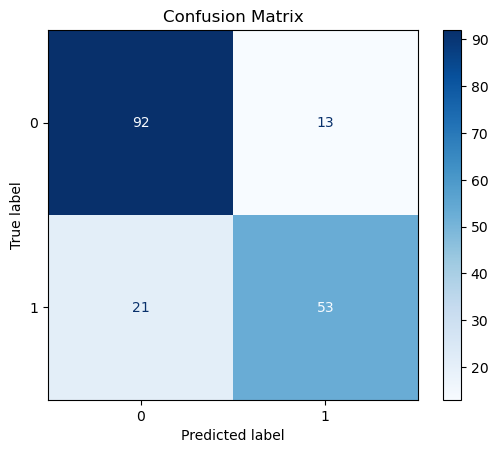

In [188]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict using the model
y_pred = pipe.predict(X_test)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

Room for improvement = Extract the title of people as it contains hidden info.

## Updated model for learning fastapi

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVC
import joblib
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# 2. FEATURE ENGINEERING (These will become @computed_fields in FastAPI later)
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
rare_titles = ['Dr', 'Rev', 'Col', 'Major', 'Count', 'Don', 'Jonkheer', 'Capt', 'Lady', 'Sir', 'Mme', 'Ms', 'Mlle']
df['Title'] = df['Title'].replace(rare_titles, 'Other')

df['Members'] = df['SibSp'] + df['Parch']
df['IsAlone'] = (df['Members'] == 0).astype(int)
df['FarePerPerson'] = df['Fare'] / (df['Members'] + 1)

# 3. HANDLE MISSING VALUES
# Age: Fill with median of their specific Passenger Class
df['Age'] = df['Age'].fillna(df.groupby('Pclass')['Age'].transform('median'))
# Embarked: Fill the 2 nulls with the most common port
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 4. DROP NOISY/USELESS COLUMNS, run this cell after running the below cell
df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True, errors='ignore')

# Define X and y
X = df.drop(columns=['Survived'])
y = df['Survived']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. BUILD THE MLOPS PIPELINE (Using explicit column names for safety)
numeric_features = ['Age', 'Fare', 'Members', 'FarePerPerson']
categorical_features = ['Sex', 'Embarked', 'Title', 'Pclass', 'IsAlone']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

# Combine Preprocessor and SVM into one single object
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', probability=True, random_state=42))
])

# 6. TRAIN AND EXPORT
pipe.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [18]:
y_pred = pipe.predict(X_test)
y_pred

array([1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 1])

✅ Overall Model Accuracy: 82.68%

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       105
           1       0.81      0.76      0.78        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



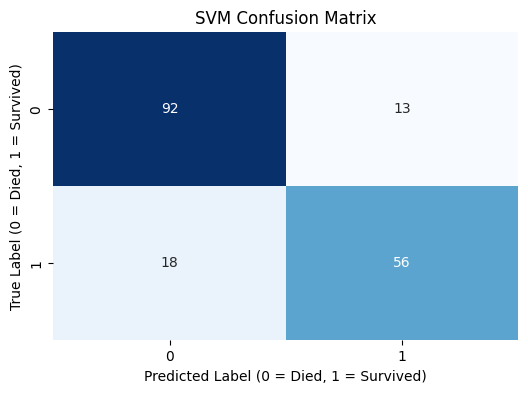

In [19]:
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Overall Model Accuracy: {accuracy * 100:.2f}%\n")


print("📊 Classification Report:")
print(classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted Label (0 = Died, 1 = Survived)")
plt.ylabel("True Label (0 = Died, 1 = Survived)")
plt.show()

In [20]:
joblib.dump(pipe, 'titanic_svm_pipeline.pkl')
print("✅ Pipeline trained and saved successfully as 'titanic_svm_pipeline.pkl'")

✅ Pipeline trained and saved successfully as 'titanic_svm_pipeline.pkl'
